Mounted at /content/drive
Extracting dataset...
Done.
Path to dataset files: /content/cifake_dataset


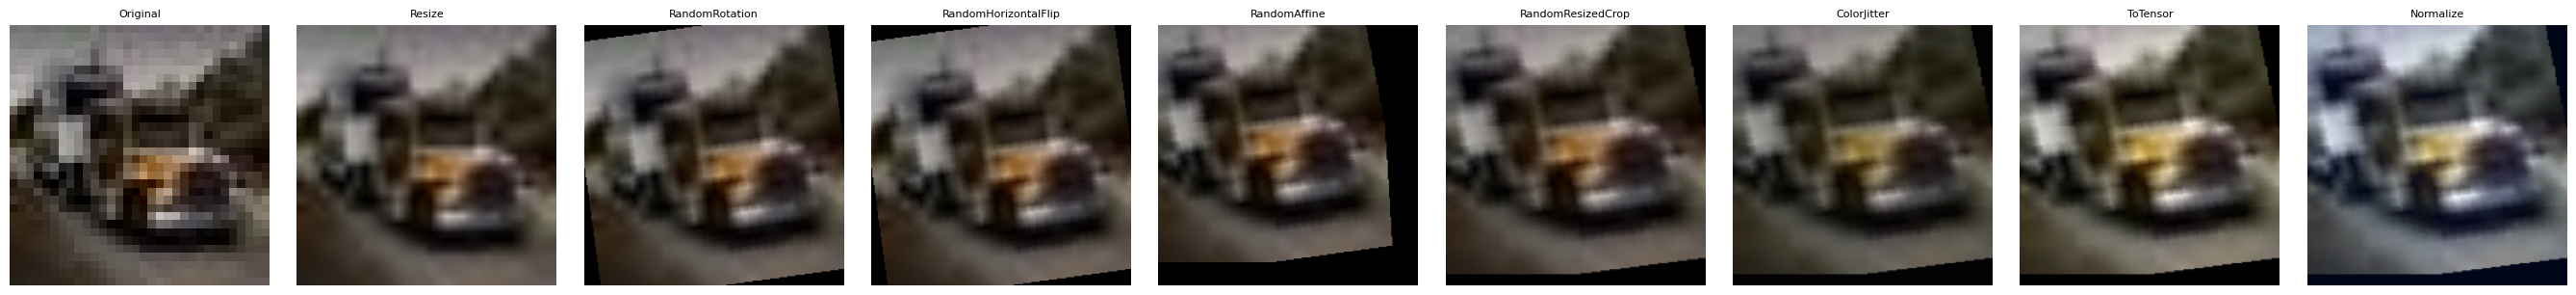

Classes: {'FAKE': 0, 'REAL': 1}
Training samples: 99000, Validation samples: 11000, Test samples: 20000
FAKE: 60000, REAL: 50000, pos_weight: 1.200

Model parameters: 719,745


In [ ]:
#import all necessary libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

#Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_PHASE1 = 25  # First block: trained fresh, then checkpointed
EPOCHS_PHASE2 = 25  # Second block: resumes from the Phase 1 checkpoint
DEVICE = torch.device("cuda")

# ViT hyperparameters
PATCH_SIZE = 16  # Standard patch size for 224x224 input
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 196 patches
PROJECTION_DIM = 128
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4
MLP_DIM = PROJECTION_DIM * 2
DROPOUT = 0.1

# Augmented Dataset is loaded from Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# Extract dataset from zip
zip_path = "/content/drive/MyDrive/Dissertation/cifake_dataset.zip"
extract_to = "/content/cifake_dataset"
if not os.path.exists(extract_to):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")
    print("Done.")
DATASET_DIR = extract_to
print("Path to dataset files:", DATASET_DIR)

#Data Loading
train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# Preprocessing and Data Augmentation
# ViTs lack CNN inductive biases so stronger augmentation is used to improve generalisation.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Data Augmentation
    transforms.RandomRotation(20),             # Randomly rotate images up to ±20 degrees
    transforms.RandomHorizontalFlip(),         # Randomly mirror images horizontally
    transforms.RandomAffine(                   # Random translation and shear
        degrees=0,
        translate=(0.2, 0.2),                  # Shift up to 20% horizontally/vertically
        shear=10,                              # Apply random shear transformations
    ),
    transforms.RandomResizedCrop(              # Random zoom via crop and resize
        IMG_SIZE, scale=(0.8, 1.0),
    ),
    transforms.ColorJitter(                    # Colour jitter
        brightness=0.1, contrast=0.1,
        saturation=0.1, hue=0.05,
    ),
    # Preprocessing
    transforms.ToTensor(),                     # Convert to tensor and scale to [0, 1]
    transforms.Normalize(                      # Standardize
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Preprocessing only, no augmentation applied to test data
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# visualize Augmentation Pipeline
def to_displayable(img):
    if isinstance(img, Image.Image):
        return np.array(img) / 255.0
    arr = img.permute(1, 2, 0).numpy()
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)


sample_path = datasets.ImageFolder(train_dir).samples[0][0]
raw_img = Image.open(sample_path).convert("RGB")

pipeline_steps = [("Original", raw_img)]
current = raw_img
for t in train_transform.transforms:
    current = t(current)
    pipeline_steps.append((type(t).__name__, current))

fig, axes = plt.subplots(1, len(pipeline_steps), figsize=(3 * len(pipeline_steps), 3))
for ax, (name, img) in zip(axes, pipeline_steps):
    ax.imshow(to_displayable(img))
    ax.set_title(name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig("vit_augmentation_pipeline.png", dpi=150)
plt.show()

# Load datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
# Separate, untransformed copy so the validation split isn't randomly augmented each epoch
full_train_dataset_eval = datasets.ImageFolder(train_dir, transform=test_transform)

# Reserve 10% of training data for validation
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_indices, val_indices = random_split(range(len(full_train_dataset)), [train_size, val_size])
train_dataset = Subset(full_train_dataset, train_indices.indices)
val_dataset = Subset(full_train_dataset_eval, val_indices.indices)

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Classes: {full_train_dataset.class_to_idx}")
print(f"Training samples: {train_size}, Validation samples: {val_size}, Test samples: {len(test_dataset)}")

# GAN augmentation adds images to FAKE only, skewing the class balance.
# Compute pos_weight from the actual counts rather than hardcoding a ratio
class_counts = np.bincount([label for _, label in full_train_dataset.samples])
fake_count, real_count = class_counts[0], class_counts[1]
pos_weight = torch.tensor([fake_count / real_count], device=DEVICE)
print(f"FAKE: {fake_count}, REAL: {real_count}, pos_weight: {pos_weight.item():.3f}")


#ViT Components

class PatchEmbedding(nn.Module):
    """Extract patches and project them to embedding dimension."""

    def __init__(self, img_size, patch_size, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # Use Conv2d as an efficient patch extraction + linear projection
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x: (batch, channels, height, width)
        x = self.projection(x)          # (batch, embed_dim, num_patches_h, num_patches_w)
        x = x.flatten(2).transpose(1, 2)  # (batch, num_patches, embed_dim)
        x = x + self.position_embedding   # Add positional embeddings
        return x


class TransformerBlock(nn.Module):
    """Single transformer encoder block."""

    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Self attention with pre normalization and skip connection
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out

        # MLP with pre normalization and skip connection
        x_norm = self.norm2(x)
        x = x + self.mlp(x_norm)
        return x


class VisionTransformer(nn.Module):
    """Vision Transformer for binary classification."""

    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=128,
                 num_heads=4, num_layers=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)

        # Transformer encoder
        self.transformer = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, mlp_dim, dropout) for _ in range(num_layers)]
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.3)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.patch_embed(x)      # (batch, num_patches, embed_dim)
        x = self.transformer(x)      # (batch, num_patches, embed_dim)
        x = self.norm(x)
        x = x.mean(dim=1)            # Global average pooling over patches
        x = self.dropout(x)
        x = self.head(x)
        return x


#Build Model
model = VisionTransformer(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=PROJECTION_DIM,
    num_heads=NUM_HEADS,
    num_layers=TRANSFORMER_LAYERS,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT,
).to(DEVICE)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

#Training Setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Checkpoints to train model in phases due to colab usage limitations.
save_dir = "/content/drive/MyDrive/Dissertation"
os.makedirs(save_dir, exist_ok=True)
phase1_checkpoint_path = os.path.join(save_dir, "cifake_vit_phase1_checkpoint.pth")
patience = 10  # shared by both phases


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.float().to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.float().to(DEVICE)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
#Training Block 1 (epochs 1-25) with Early Stopping
if os.path.exists(phase1_checkpoint_path):
    print(f"Block 1 checkpoint already exists at {phase1_checkpoint_path} — skipping Block 1")
else:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    print("\n=== Training Block 1 ===")
    for epoch in range(EPOCHS_PHASE1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{EPOCHS_PHASE1} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.1e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    phase1_epochs = len(history["accuracy"])

    # Save Block 1 checkpoint
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "phase1_epochs": phase1_epochs,
        "best_val_loss": best_val_loss,
        "history": history,
    }, phase1_checkpoint_path)
    print(f"Block 1 checkpoint saved to {phase1_checkpoint_path}")


=== Training Block 1 ===
Epoch 1/25 - loss: 0.6221 - acc: 0.6979 - val_loss: 0.5225 - val_acc: 0.7765 - lr: 1.0e-03
Epoch 2/25 - loss: 0.4826 - acc: 0.7961 - val_loss: 0.4432 - val_acc: 0.8220 - lr: 1.0e-03
Epoch 3/25 - loss: 0.4232 - acc: 0.8276 - val_loss: 0.3809 - val_acc: 0.8487 - lr: 1.0e-03
Epoch 4/25 - loss: 0.3931 - acc: 0.8439 - val_loss: 0.4375 - val_acc: 0.8335 - lr: 1.0e-03
Epoch 5/25 - loss: 0.3766 - acc: 0.8522 - val_loss: 0.3340 - val_acc: 0.8765 - lr: 1.0e-03
Epoch 6/25 - loss: 0.3647 - acc: 0.8574 - val_loss: 0.3646 - val_acc: 0.8550 - lr: 1.0e-03
Epoch 7/25 - loss: 0.3544 - acc: 0.8622 - val_loss: 0.3587 - val_acc: 0.8743 - lr: 1.0e-03
Epoch 8/25 - loss: 0.3392 - acc: 0.8689 - val_loss: 0.3075 - val_acc: 0.8884 - lr: 1.0e-03
Epoch 9/25 - loss: 0.3344 - acc: 0.8708 - val_loss: 0.2846 - val_acc: 0.8918 - lr: 1.0e-03
Epoch 10/25 - loss: 0.3246 - acc: 0.8747 - val_loss: 0.3424 - val_acc: 0.8755 - lr: 1.0e-03
Epoch 11/25 - loss: 0.3177 - acc: 0.8790 - val_loss: 0.2818 - v

Loaded Block 1 checkpoint (25 epochs) — resuming at Block 2

=== Training Block 2 ===
Epoch 1/25 - loss: 0.2327 - acc: 0.9138 - val_loss: 0.2979 - val_acc: 0.8913 - lr: 2.5e-04
Epoch 2/25 - loss: 0.2321 - acc: 0.9142 - val_loss: 0.2394 - val_acc: 0.9142 - lr: 2.5e-04
Epoch 3/25 - loss: 0.2310 - acc: 0.9147 - val_loss: 0.2915 - val_acc: 0.8970 - lr: 1.3e-04
Epoch 4/25 - loss: 0.2225 - acc: 0.9188 - val_loss: 0.2213 - val_acc: 0.9193 - lr: 1.3e-04
Epoch 5/25 - loss: 0.2192 - acc: 0.9195 - val_loss: 0.2778 - val_acc: 0.9030 - lr: 1.3e-04
Epoch 6/25 - loss: 0.2176 - acc: 0.9195 - val_loss: 0.2721 - val_acc: 0.9055 - lr: 1.3e-04
Epoch 7/25 - loss: 0.2171 - acc: 0.9197 - val_loss: 0.2180 - val_acc: 0.9212 - lr: 1.3e-04
Epoch 8/25 - loss: 0.2152 - acc: 0.9208 - val_loss: 0.2430 - val_acc: 0.9160 - lr: 1.3e-04
Epoch 9/25 - loss: 0.2154 - acc: 0.9210 - val_loss: 0.2144 - val_acc: 0.9231 - lr: 1.3e-04
Epoch 10/25 - loss: 0.2133 - acc: 0.9217 - val_loss: 0.2491 - val_acc: 0.9132 - lr: 1.3e-04
Epo

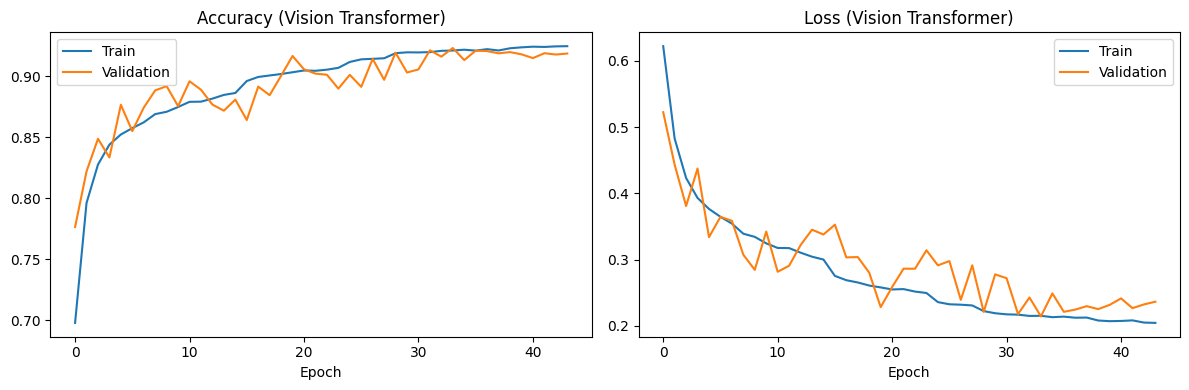

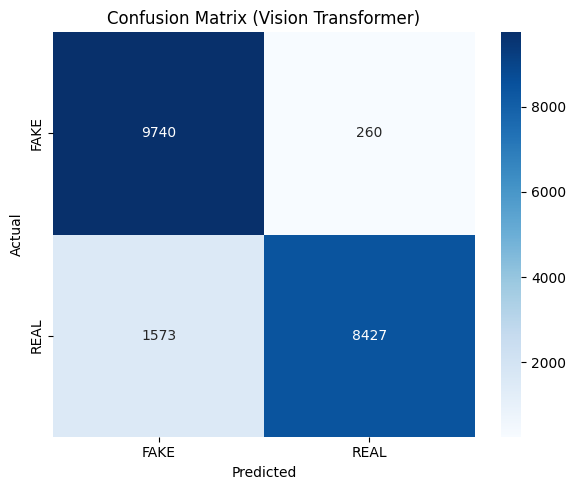

Model saved to /content/drive/MyDrive/Dissertation/cifake_vit_model.pth


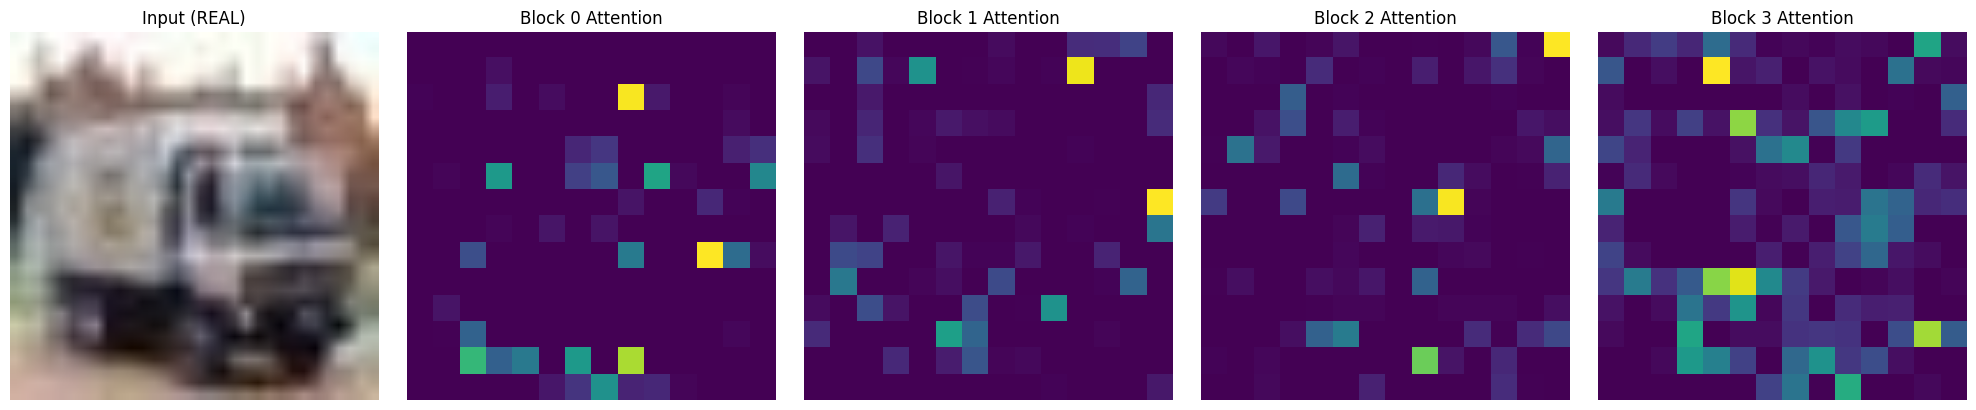

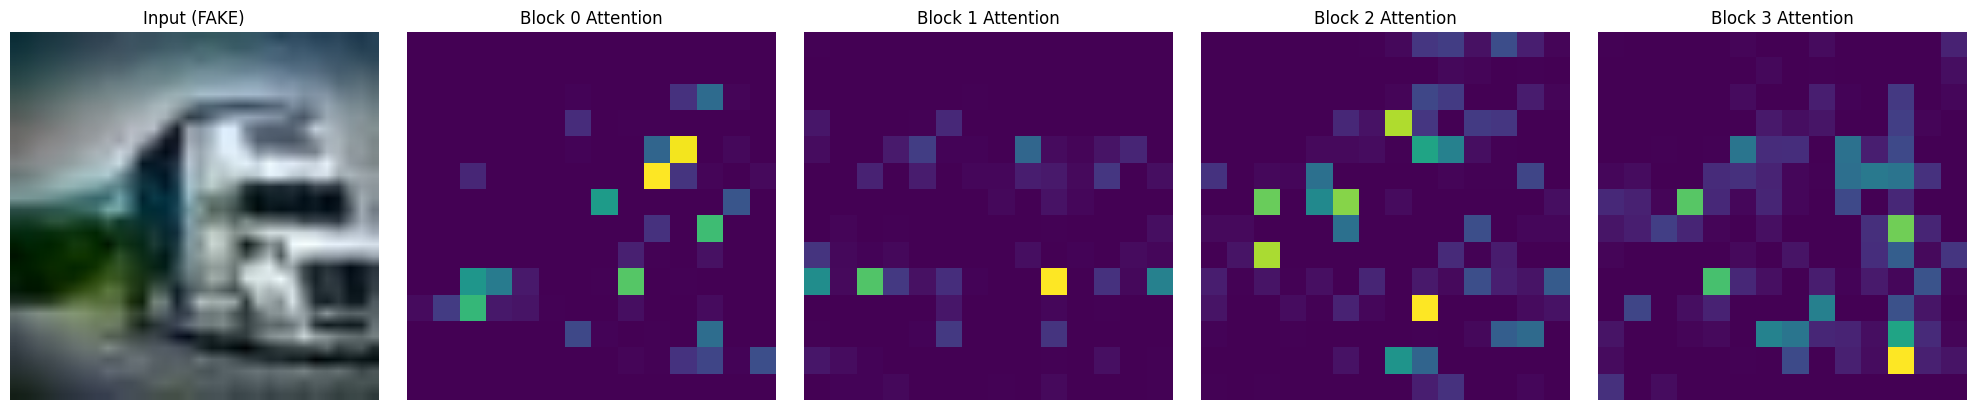

In [2]:
#Training Block 2 (epochs 26-50)
ckpt = torch.load(phase1_checkpoint_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
best_val_loss = ckpt["best_val_loss"]
phase1_epochs = ckpt["phase1_epochs"]

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
optimizer.load_state_dict(ckpt["optimizer_state_dict"])
scheduler.load_state_dict(ckpt["scheduler_state_dict"])
print(f"Loaded Block 1 checkpoint ({phase1_epochs} epochs) — resuming at Block 2")

print("\n=== Training Block 2 ===")
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS_PHASE2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{EPOCHS_PHASE2} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Restore best weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)

#Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred_probs = np.array(all_preds)
y_pred = (y_pred_probs > 0.5).astype(int)

test_acc = (y_pred == y_true).mean()
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))

#Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["accuracy"], label="Train")
axes[0].plot(history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy (Vision Transformer)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].set_title("Loss (Vision Transformer)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("vit_training_history.png", dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Vision Transformer)")
plt.tight_layout()
plt.savefig("vit_confusion_matrix.png", dpi=150)
plt.show()

#Save Model
save_path = os.path.join(save_dir, "cifake_vit_model.pth")

torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

#Attention Map Visualisation
# ViT self attention weights per block are visualised

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


# One REAL and one FAKE test image so attention can be compared side by side
real_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 1)
fake_idx = next(i for i, (_, label) in enumerate(test_dataset.samples) if label == 0)
sample_images = {
    "REAL": test_dataset[real_idx][0].unsqueeze(0).to(DEVICE),
    "FAKE": test_dataset[fake_idx][0].unsqueeze(0).to(DEVICE),
}

grid_size = IMG_SIZE // PATCH_SIZE
attn_maps = {}


def make_hook(name):
    def hook(module, input, output):
        attn_maps[name] = output[1].detach().cpu()  # (batch, num_patches, num_patches)
    return hook


hooks = [block.attn.register_forward_hook(make_hook(f"block{i}")) for i, block in enumerate(model.transformer)]

model.eval()
for label, img in sample_images.items():
    attn_maps.clear()
    with torch.no_grad():
        model(img)

    num_blocks = len(model.transformer)
    fig, axes = plt.subplots(1, num_blocks + 1, figsize=(4 * (num_blocks + 1), 4))
    axes[0].imshow(denormalize(img[0]).permute(1, 2, 0).numpy())
    axes[0].set_title(f"Input ({label})")
    axes[0].axis("off")

    for i in range(num_blocks):
        # Average attention each patch receives from all other patches
        attn = attn_maps[f"block{i}"][0].mean(dim=0).reshape(grid_size, grid_size)
        axes[i + 1].imshow(attn.numpy(), cmap="viridis")
        axes[i + 1].set_title(f"Block {i} Attention")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.savefig(f"vit_attention_maps_{label.lower()}.png", dpi=150)
    plt.show()

for h in hooks:
    h.remove()